In [1]:
import sys
print("Python:", sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
print(" All imports OK")


Python: c:\Users\theer\OneDrive\Desktop\PEP-ML-Sales-Forecasting\.venv\Scripts\python.exe
 All imports OK


In [2]:
import pandas as pd
import numpy as np

date_range = pd.date_range(start="2018-01-01", end="2022-12-31", freq="M")
np.random.seed(42)
trend = np.linspace(1000, 2000, len(date_range))
seasonality = 200 * np.sin(2 * np.pi * date_range.month / 12)
noise = np.random.normal(0, 100, len(date_range))

sales = trend + seasonality + noise
df = pd.DataFrame({"date": date_range, "sales": sales.round(0)})

print(df.head())
print(" Synthetic retail sales data created:", df.shape)


        date   sales
0 2018-01-31  1150.0
1 2018-02-28  1176.0
2 2018-03-31  1299.0
3 2018-04-30  1376.0
4 2018-05-31  1144.0
 Synthetic retail sales data created: (60, 2)


In [3]:
# Ensure datetime and sort (for real data safety)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Set date as index and fix frequency to monthly
df_ts = df.set_index('date')
ts = df_ts['sales'].asfreq('M')

print("Time series length:", len(ts))
print("Frequency:", ts.index.freq)
print(ts.head())
print(" Time series prepared")


Time series length: 60
Frequency: <MonthEnd>
date
2018-01-31    1150.0
2018-02-28    1176.0
2018-03-31    1299.0
2018-04-30    1376.0
2018-05-31    1144.0
Freq: ME, Name: sales, dtype: float64
 Time series prepared


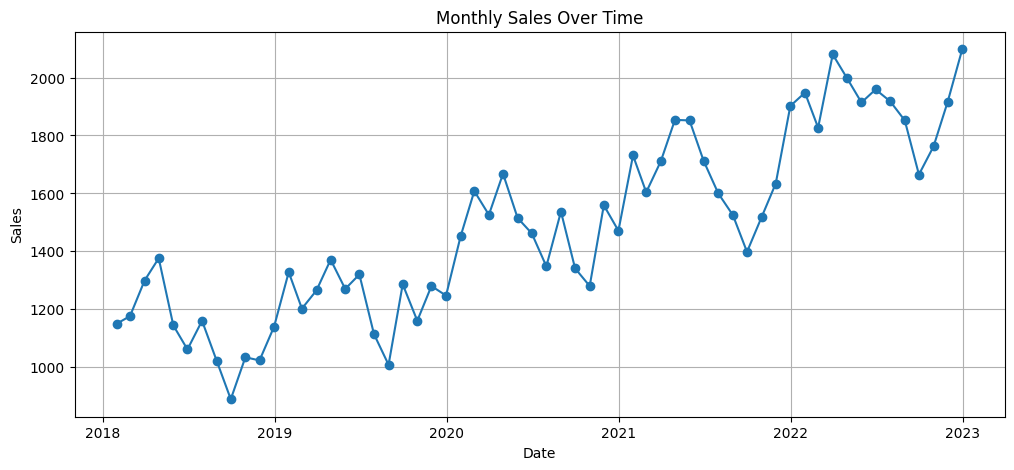

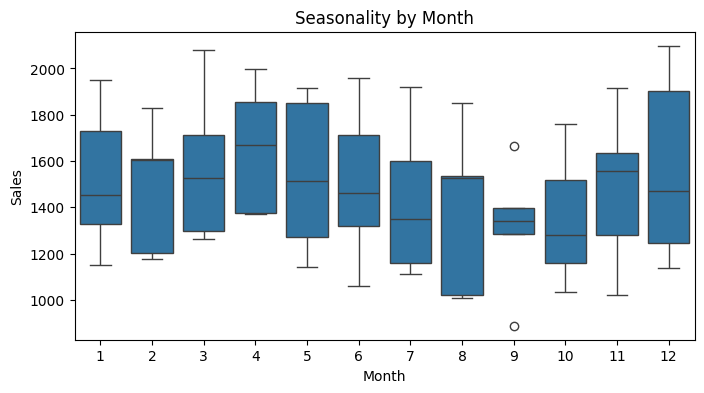

In [12]:
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, marker='o')
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.savefig("images/sales_over_time.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8,4))
sns.boxplot(x=ts.index.month, y=ts.values)
plt.title("Seasonality by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("images/seasonality_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()



In [5]:
from math import ceil

# 80% train, 20% test
split_index = ceil(len(ts) * 0.8)
train = ts.iloc[:split_index]
test = ts.iloc[split_index:]

print("Train length:", len(train), "Test length:", len(test))
print("Train start:", train.index[0], "→", train.index[-1])
print("Test  start:", test.index[0], "→", test.index[-1])


Train length: 48 Test length: 12
Train start: 2018-01-31 00:00:00 → 2021-12-31 00:00:00
Test  start: 2022-01-31 00:00:00 → 2022-12-31 00:00:00


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1, 1, 1),          # ARIMA(p,d,q)
    seasonal_order=(1, 1, 1, 12),  # SARIMA(P,D,Q, s=12 months)
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(" SARIMA fitted")


 SARIMA fitted


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Forecast for test period
pred = model_fit.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

pred_mean.index = test.index
pred_ci.index = test.index

# MAE
mae = mean_absolute_error(test, pred_mean)

# Old-style RMSE (no squared parameter)
mse = mean_squared_error(test, pred_mean)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 80.78
RMSE: 95.85


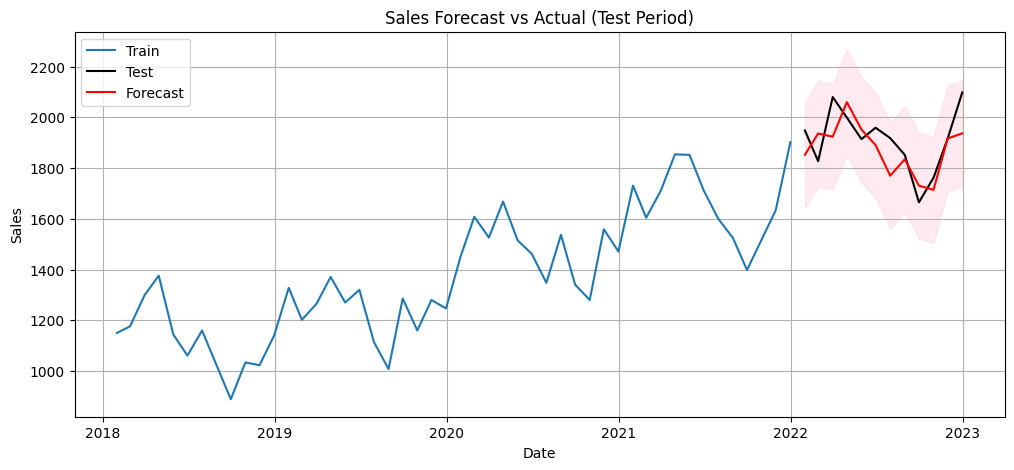

In [13]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test", color="black")
plt.plot(pred_mean.index, pred_mean.values, label="Forecast", color="red")
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:,0],
                 pred_ci.iloc[:,1],
                 color='pink', alpha=0.3)
plt.title("Sales Forecast vs Actual (Test Period)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("images/forecast_test.png", dpi=300, bbox_inches="tight")
plt.show()



In [10]:
# Refit SARIMA on full series for future forecast
final_model = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_model.fit(disp=False)

# Forecast next 12 months
future_steps = 12
future_pred = final_fit.get_forecast(steps=future_steps)
future_mean = future_pred.predicted_mean

print("Next 12 months forecast:")
print(future_mean)


Next 12 months forecast:
2023-01-31    2185.217602
2023-02-28    2065.939634
2023-03-31    2305.713404
2023-04-30    2245.401114
2023-05-31    2168.059892
2023-06-30    2195.995441
2023-07-31    2148.446301
2023-08-31    2081.616128
2023-09-30    1900.150638
2023-10-31    1999.272200
2023-11-30    2149.767011
2023-12-31    2339.699808
Freq: ME, Name: predicted_mean, dtype: float64


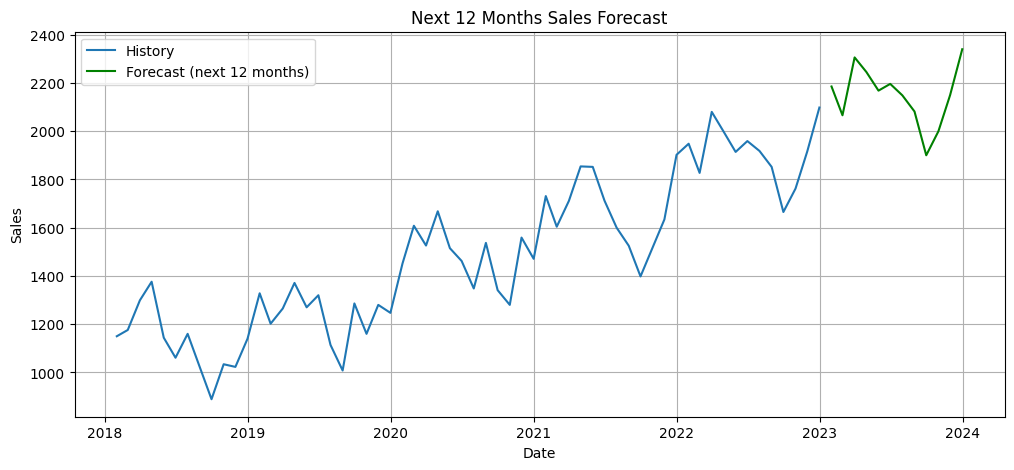

In [14]:
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label="History")
plt.plot(future_mean.index, future_mean.values, label="Forecast (next 12 months)", color="green")
plt.title("Next 12 Months Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("images/forecast_next_12_months.png", dpi=300, bbox_inches="tight")
plt.show()

